In [18]:
import ftlelab as fl
# import ftlelab.configs as cfg
import ftlelab.models as fmods
import torch

import ftlelab.utils as utils
import ftlelab.data as datasets
import ftlelab.training as training

import jax
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
from ftlelab.ftle.jax_transfer import pytorch_dense_to_jax_params
from ftlelab.ftle.jax_core import ftle_field_batched
# jax.config.update("jax_enable_x64", True)
import ftlelab.ftle as ftle

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
experiment_name = "9-grids-datasets-batched-initializations"

# 1. Datasets

In [20]:
total_size = 15000
train_size = int(0.8 * total_size)

In [21]:
batch_size=256

In [22]:
### Circles
X_circ, y_circ = datasets.make_circle_dataset(num_samples=total_size,
                                              noise_std=0.0,
                                              seed=42)

data_circ = datasets.make_dataloaders(datasets.split_dataset(X_circ, y_circ, seed=42), batch_size=batch_size)

### Moons
X_moons, y_moons = datasets.make_moons_dataset(num_samples=total_size,
                                               noise_std=0.0,
                                               seed=42)
data_moons = datasets.make_dataloaders(datasets.split_dataset(X_moons, y_moons, seed=42), batch_size=batch_size)

### Spirals
X_spiral, y_spiral = datasets.make_spiral_dataset(num_samples=total_size,
                                                  noise_std=0.0,
                                                  seed=42)
data_spiral = datasets.make_dataloaders(datasets.split_dataset(X_spiral, y_spiral, seed=42), batch_size=batch_size)

### Xor
X_xor, y_xor = datasets.make_xor_dataset(num_samples=total_size,
                                         noise_std=0.0,
                                         seed=42)
data_xor = datasets.make_dataloaders(datasets.split_dataset(X_xor, y_xor, seed=42), batch_size=batch_size)

In [23]:
dataset_names = ["circle", "moons", "spiral", "xor"]
datasets_dict = {
    "circle": data_circ,
    "moons": data_moons,
    "spiral": data_spiral,
    "xor": data_xor,
}

In [25]:
activations = ["tanh", "relu", "leaky_relu", "gelu", "softplus"]

## 2. Experimentation

In [26]:
ell_list = [2, 4, 8, 12]
n_list = [5, 10, 50, 250]

### 2.1. Tanh

In [27]:
networks_grid_configs = {}

for dataset_name in dataset_names:
    networks_grid_configs[dataset_name] = {}
    for activation in activations:
        networks_grid_configs[dataset_name][activation] = {}
        for n in n_list:
            for ell in ell_list: 
                config_key = f"({n}, {ell})-{dataset_name}-{activation}"
                layer_sizes = [2] + [n] * ell + [1]
                networks_grid_configs[dataset_name][activation][config_key] = {
                    "net_params": {
                        "layer_dims": layer_sizes,
                        "init_method": "xavier" if activation in ("tanh", "sigmoid") else "he",
                        "activation": activation,
                        "output_activation": "tanh",
                    },
                    "train_config":
                    training.TrainConfig(
                        lr=1e-2, 
                        epochs=200, # 2500,
                        batch_size=batch_size, # 256,
                        loss='mse',
                        optimizer='sgd',
                        weight_decay=0.0,
                        save_dir=f'experiment_{experiment_name}/{dataset_name}/{activation}',
                        model_name=f"__batch-{batch_size}__{config_key}",
                        momentum=0.0,
                        print_every=100, #200
                    )
                }

In [35]:
for dataset_name in dataset_names[1:]:
    for activation in activations:
        for network in tqdm(networks_grid_configs[dataset_name][activation].keys()):
            net = fmods.DenseNet(**networks_grid_configs[dataset_name][activation][network]["net_params"])

            trainer = training.Trainer(net, networks_grid_configs[dataset_name][activation][network]["train_config"])
            trainer.train(datasets_dict[dataset_name]['train'], datasets_dict[dataset_name]['val'])

  0%|          | 0/16 [00:00<?, ?it/s]

Trainer for MODEL___batch-256__(5, 2)-moons-tanh initialized on device: cuda
Trainable parameters: 51 / 51
Training started...


Epoch 100/200 [Validation]: 100%|██████████| 8/8 [00:00<00:00, 202.02it/s]


Epoch 100/200 | Train Loss: 0.0059 | Val Loss: 0.0057 | Val accuracy: 1.0000
Validation loss improved from 0.0058 to 0.0057. Saving best model.


  6%|▋         | 1/16 [01:07<16:58, 67.89s/it]

...

Epoch 200/200 | Train Loss: 2.0157 | Val Loss: 2.0156 | Val accuracy: 0.4961
Training finished.
Trainer for MODEL___batch-256__(250, 12)-xor-softplus initialized on device: cuda
Trainable parameters: 691,251 / 691,251
Training started...


Epoch 100/200 [Validation]: 100%|██████████| 8/8 [00:00<00:00, 291.09it/s]


Epoch 100/200 | Train Loss: 1.9843 | Val Loss: 1.9844 | Val accuracy: 0.5039


100%|██████████| 16/16 [12:47<00:00, 47.98s/it]

Epoch 200/200 | Train Loss: 1.9843 | Val Loss: 1.9844 | Val accuracy: 0.5039
Training finished.


#### Model Loading

In [81]:
networks_grid = {}
for dataset_name in dataset_names:
    networks_grid[dataset_name] = {}
    for activation in activations:
        networks_grid[dataset_name][activation] = {}
        for network in networks_grid_configs[dataset_name][activation].keys():
            config = networks_grid_configs[dataset_name][activation][network]
            net = fmods.DenseNet(**config["net_params"])
            loaded_net = torch.load(f'experiment_{experiment_name}/{dataset_name}/{activation}/LAST_CHECKPOINT__batch-256__{network}.pt')
            net.load_state_dict(loaded_net['model_state_dict'])
            net.eval()
            networks_grid[dataset_name][activation][network] = net

In [82]:
nx, ny = 200, 200

# circ
grid_circ, (XX, YY) = ftle.make_grid2d(-1.01, 1.01, -1.01, 1.01, nx=nx, ny=ny)
grid_circ_jax = jnp.asarray(grid_circ.numpy())

# moons
grid_moons, (XX_m, YY_m) = ftle.make_grid2d(-2, 2, -1.75, 2.25, nx=nx, ny=ny)
grid_moons_jax = jnp.asarray(grid_moons.numpy())

# spiral 
grid_spiral, (XX_s, YY_s) = ftle.make_grid2d(-2.2, 2.2, -2.2, 2.2, nx=nx, ny=ny)
grid_spiral_jax = jnp.asarray(grid_spiral.numpy())


# xor
grid_xor_jax = grid_circ_jax

In [83]:
grids_jax = {
    "circle": grid_circ_jax,
    "moons": grid_moons_jax,
    "spiral": grid_spiral_jax,
    "xor": grid_xor_jax
}

In [ ]:
networks_grid_ftle = {}
for dataset_name in dataset_names:
    networks_grid_ftle[dataset_name] = {}
    for activation in activations:
        networks_grid_ftle[dataset_name][activation] = {}
        for network in networks_grid[dataset_name][activation].keys():
            net = networks_grid[dataset_name][activation][network]
        

            params_jax = pytorch_dense_to_jax_params(net)      

            lam_np = ftle_field_batched(
                model_type="dense",
                params=params_jax,
                X_np=grids_jax[dataset_name],
                layer_spec= "output",#("hidden_k", net.hidden_depth),
                time_L=net.hidden_depth + 1,
                batch_size=2048,
                activation=activation,
                output_activation="tanh",
                dtype="float32",
                max_steps=30
            )
            lam_np.reshape(YY.shape)

            networks_grid_ftle[dataset_name][activation][f"{network}-ftle_field"] = lam_np

In [85]:
np.save(f"experiment_{experiment_name}/networks_grid_ftle_final.npy", networks_grid_ftle)

In [104]:
networks_grid_ftle_loaded = np.load(f"experiment_{experiment_name}/networks_grid_ftle.npy", allow_pickle=True).item()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_ftle_grid_4x4(
    networks_grid_ftle,
    dataset_name,
    activation,
    ell_list=[2, 4, 8, 12],
    n_list=[5, 10, 50, 250],
    network_order=None,
    nx=200,
    ny=200,
    extent=(-1.5, 1.5, -1.5, 1.5),
    cmap="RdBu_r",
    vmin=-3,
    vcenter=0,
    vmax=3,
    multiply_by_L=True,
    figsize=(18, 18),
    dpi=100,
    add_index=True,
):
    """
    Plot a 4x4 FTLE grid:
      rows    -> L values from ell_list
      columns -> N values from n_list

    Expected dictionary structure:
      networks_grid_ftle[dataset_name][activation][network] = net

    Assumptions:
    - each `net` is a flat FTLE field of length nx * ny, OR already shape (ny, nx)
    - network_order, if provided, must contain 16 network keys in row-major order:
        [(L=ell_list[0], N=n_list[0]), ..., (L=ell_list[0], N=n_list[3]),
         (L=ell_list[1], N=n_list[0]), ..., (L=ell_list[3], N=n_list[3])]
    - if network_order is None, insertion order of the dict values is used
    """

    data_dict = networks_grid_ftle[dataset_name][activation]

    if network_order is None:
        network_keys = list(data_dict.keys())
        if len(network_keys) != len(ell_list) * len(n_list):
            raise ValueError(
                "network_order was not provided, but the number of networks "
                f"({len(network_keys)}) does not match {len(ell_list) * len(n_list)}."
            )
    else:
        network_keys = list(network_order)
        if len(network_keys) != len(ell_list) * len(n_list):
            raise ValueError(
                f"network_order must have {len(ell_list) * len(n_list)} entries."
            )

    fig = plt.figure(constrained_layout=True, figsize=figsize, dpi=dpi)
    axes = fig.subplots(len(ell_list), len(n_list))

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    im = None

    for i, net_key in enumerate(network_keys):
        c = i // len(n_list)   # col -> L
        r = i % len(n_list)    # row -> N
        ax = axes[r, c]

        result = data_dict[net_key]

        arr = np.asarray(result)
        if arr.ndim == 1:
            field = arr.reshape(ny, nx)
        elif arr.ndim == 2:
            field = arr
        else:
            raise ValueError(
                f"Network '{net_key}' has unsupported shape {arr.shape}. "
                "Expected flat array or 2D field."
            )

        L = ell_list[c]
        plot_field = L * field if multiply_by_L else field

        im = ax.imshow(
            plot_field,
            extent=extent,
            origin="lower",
            cmap=cmap,
            alpha=0.9,
            norm=norm,
        )

        color_string = "black"
        if add_index:
            ax.text(
                -1.8, 1.5,
                f"[{i + 1}]",
                color=color_string,
                fontsize=20
            )

        # top labels for N
        if r == 0:
            ax.set_xlabel(f"L = {ell_list[c]}", fontsize=20)
            ax.xaxis.set_label_position("top")

        # left labels for L
        if c == 0:
            ax.set_ylabel(f"N = {n_list[r]}", fontsize=20)

        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        location="bottom",
        shrink=0.8,
    )
    cbar.set_label(
        r"$L\lambda^{(L)}(\mathbf{x})$" if multiply_by_L else r"$\lambda^{(L)}(\mathbf{x})$",
        fontsize=20
    )
    cbar.ax.tick_params(labelsize=20)

    plt.show()

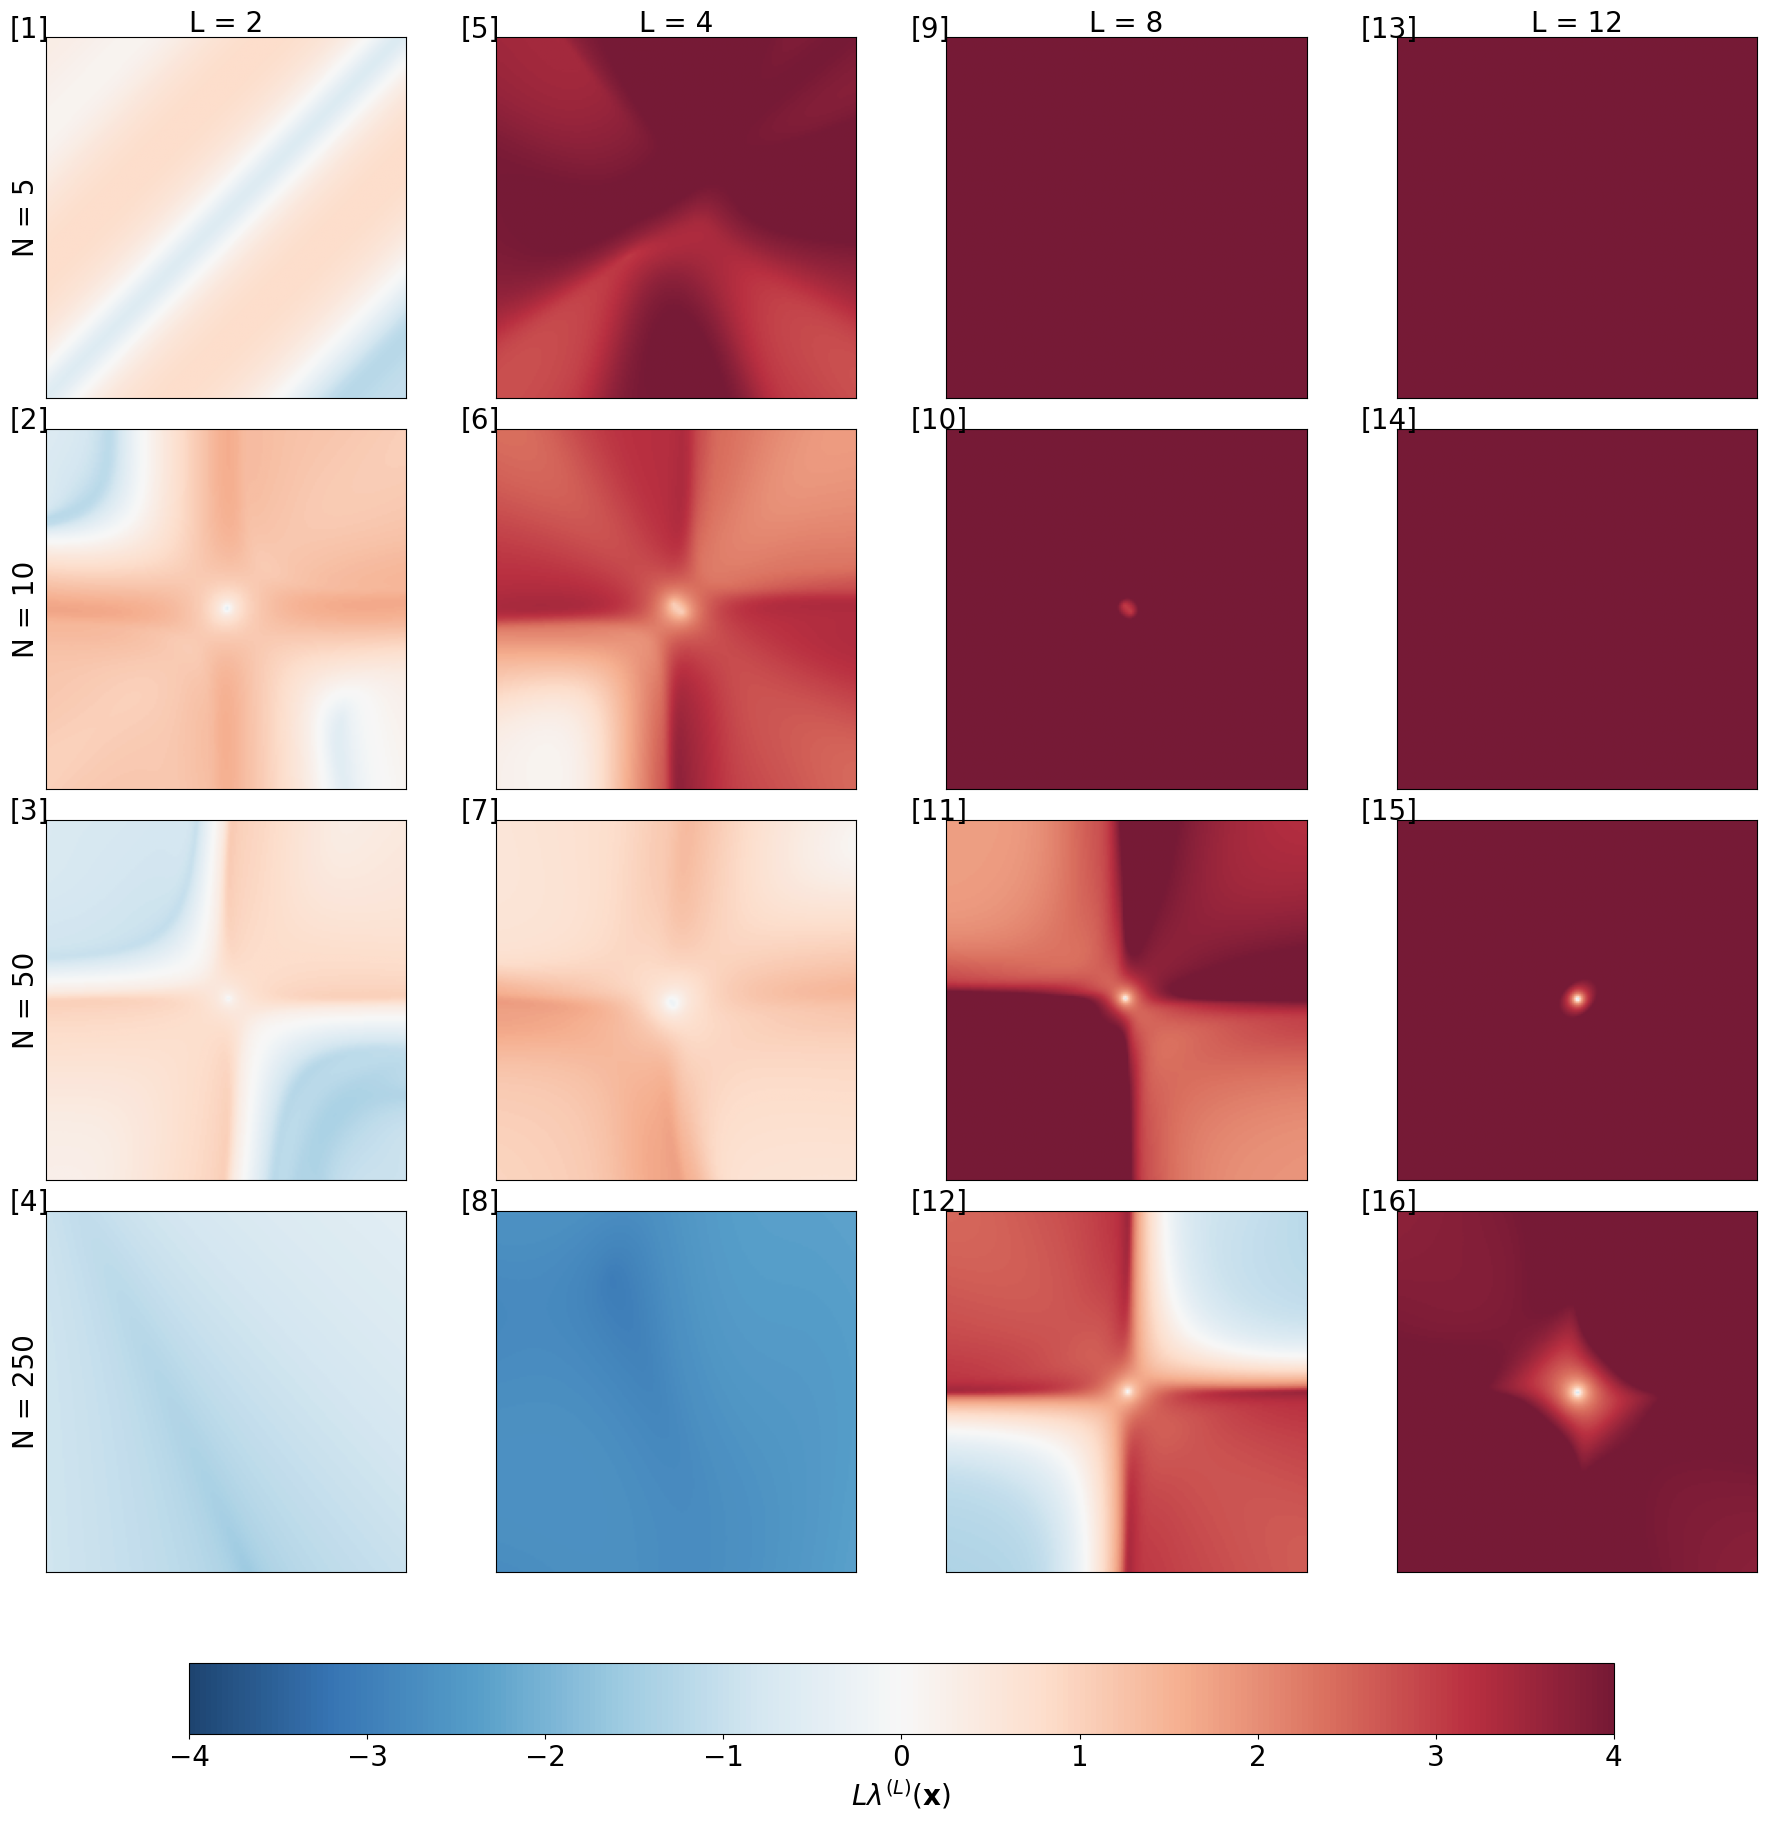

In [124]:
plot_ftle_grid_4x4(
    networks_grid_ftle_loaded,
    dataset_name="xor",
    activation="gelu",
    ell_list=[2, 4, 8, 12],
    n_list=[5, 10, 50, 250],
    nx=200,
    ny=200,
    vmin=-4,
    vmax=4,
    multiply_by_L=True
)

In [148]:
def plot_decision_grid_NL(
    networks_grid,
    dataset_name: str,
    activation: str,
    XX, YY,
    X_val, y_val,
    n_list=(5, 10, 50, 250),
    ell_list=(2, 4, 8, 12),
    network_name_template="N{N}_L{L}",
    device="cpu",
    levels=20,
    cmap="RdBu_r",
    vmin=-1.5,
    vcenter=0.0,
    vmax=1.5,
    figsize=(18, 18),
    dpi=100,
    add_index=True,
    title=None,
):
    """
    Plot decision level sets in a grid:
      rows    = depth    L  (ell_list, top label)
      columns = width    N  (n_list,   left label)

    Row/column convention mirrors plot_ftle_grid_4x4:
      ax = axes[row, col]  where row indexes ell_list and col indexes n_list.

    Parameters
    ----------
    networks_grid         : dict  [dataset_name][activation][model_name] -> nn.Module
    XX, YY                : np.ndarray  meshgrid, shape (ny, nx)
    X_val, y_val          : torch.Tensor  validation set, y in {-1, +1}
    n_list                : sequence of int  hidden-layer widths  -> columns
    ell_list              : sequence of int  number of hidden layers -> rows
    network_name_template : str  f-string with {N} and {L}
                            e.g. "N{N}_L{L}" produces "N50_L4"
    add_index             : bool  add [k] counter in top-left corner
    """
    from matplotlib.colors import TwoSlopeNorm

    nrows = len(n_list)
    ncols = len(ell_list)

    grid = torch.tensor(
        np.column_stack([XX.ravel(), YY.ravel()]),
        dtype=torch.float32,
        device=device,
    )

    X_val_d    = X_val.to(device)
    y_val_flat = y_val.view(-1).to(device)

    activation_dict = networks_grid[dataset_name][activation]
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=figsize,
        dpi=dpi,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    im      = None
    counter = 1

    for r, N in enumerate(n_list):        # rows = N
        for c, L in enumerate(ell_list):  # cols = L
            ax = axes[r, c]

            model_name = network_name_template.format(N=N, L=L)

            if model_name not in activation_dict:
                ax.text(
                    0.5, 0.5, f"Missing:\n{model_name}",
                    ha="center", va="center", fontsize=10,
                    transform=ax.transAxes,
                )
                ax.set_xticks([]); ax.set_yticks([])
                if add_index:
                    ax.text(
                        0.03, 0.94, f"[{counter}]",
                        transform=ax.transAxes,
                        color="black", fontsize=18, va="top",
                    )
                counter += 1
                continue

            model = activation_dict[model_name]
            model.eval()

            with torch.no_grad():
                preds_grid = (
                    model(grid)
                    .squeeze(-1)
                    .cpu()
                    .numpy()
                    .reshape(XX.shape)
                )

            im = ax.contourf(
                XX, YY, preds_grid,
                levels=levels,
                cmap=cmap,
                norm=norm,
            )
            ax.contour(
                XX, YY, preds_grid,
                levels=[0.0],
                colors="k",
                linewidths=0.9,
                linestyles="--",
            )

            with torch.no_grad():
                out_val  = model(X_val_d).squeeze(-1)
                pred_val = torch.where(
                    out_val >= 0.0,
                    torch.ones_like(out_val),
                    -torch.ones_like(out_val),
                )
                acc = (pred_val == y_val_flat.float()).float().mean().item()

            ax.text(
                0.03, 0.04,
                f"acc[test]={acc:.2%}",
                transform=ax.transAxes,
                fontsize=15,
                color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.45, lw=0),
            )

            if add_index:
                ax.text(
                    0.03, 0.94, f"[{counter}]",
                    transform=ax.transAxes,
                    color="black", fontsize=18, va="top",
                )

            ax.set_xticks([]); ax.set_yticks([])

            if r == 0:
                ax.set_title(f"L = {L}", fontsize=20, pad=12)   # top:  L
            if c == 0:
                ax.set_ylabel(f"N = {N}", fontsize=20,
                              rotation=90, labelpad=16)          # left: N

            counter += 1

    if im is not None:
        cbar = fig.colorbar(
            im,
            ax=axes.ravel().tolist(),
            orientation="horizontal",
            location="bottom",
            shrink=0.85,
            pad=0.04,
        )
        cbar.set_label("Network's Decision Level Sets", fontsize=20)
        cbar.ax.tick_params(labelsize=18)

    fig.suptitle(
        title or f"Decision level sets — {dataset_name} / {activation}",
        fontsize=20, y=1.02,
    )
    plt.show()

In [177]:
dataset_n = "xor"

In [185]:
activation_n = "gelu"

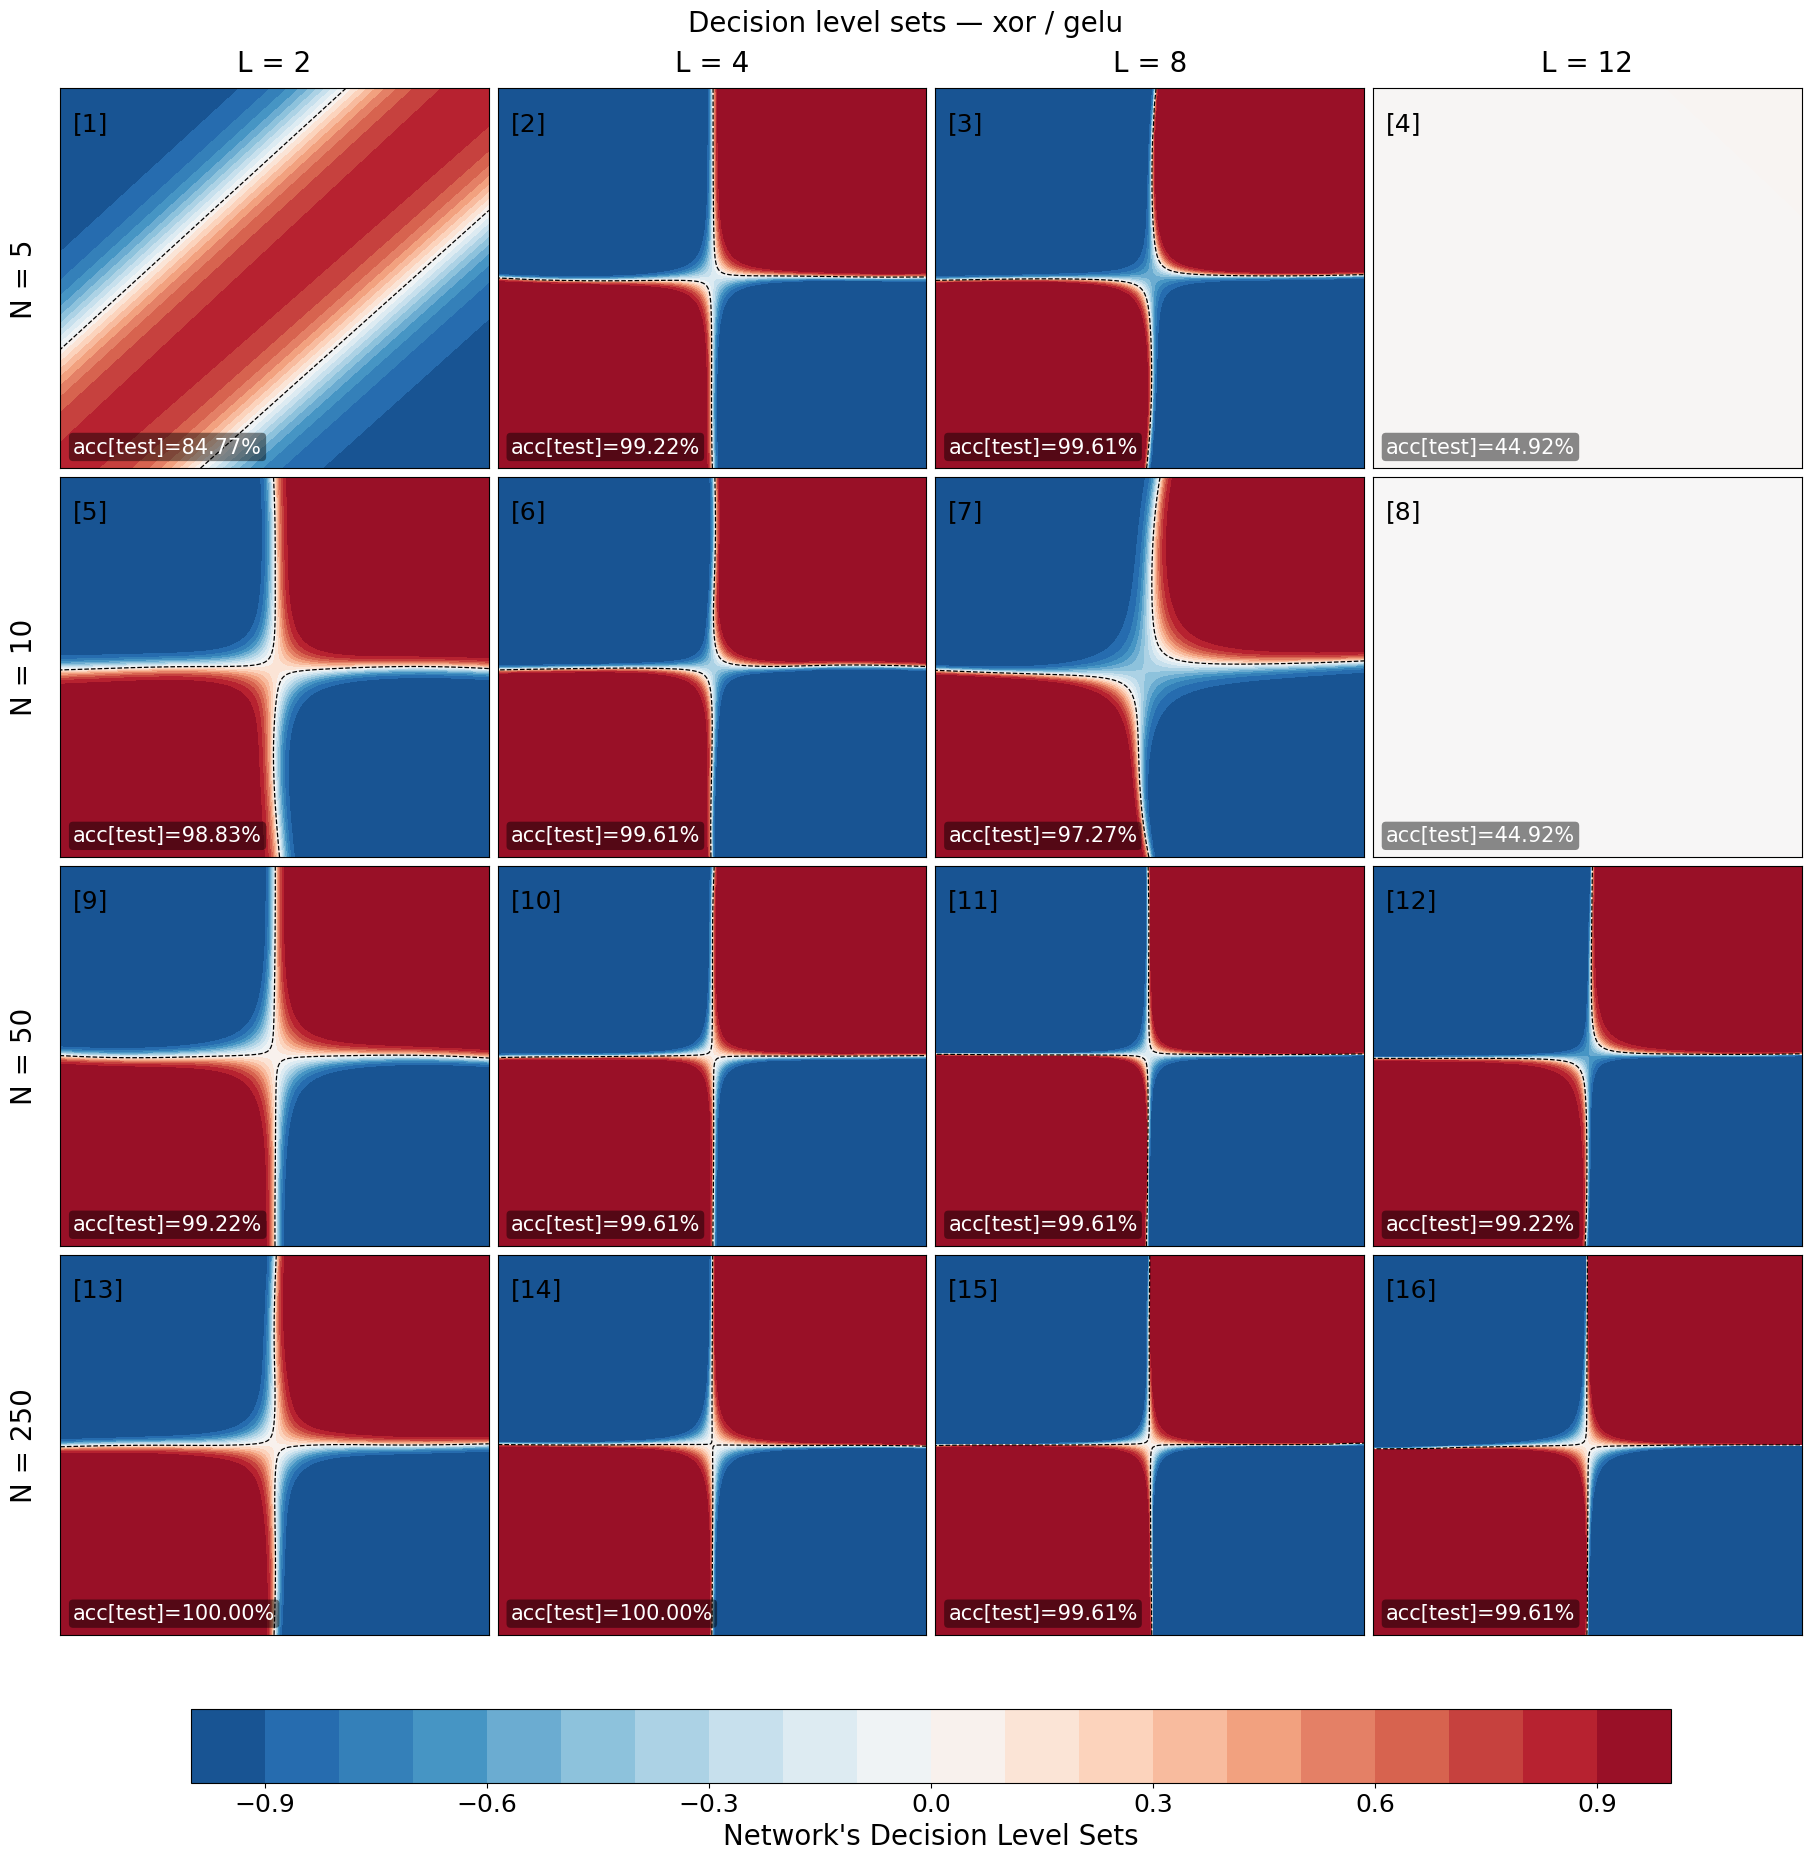

In [186]:
plot_decision_grid_NL(
    networks_grid,
    dataset_name=dataset_n,
    activation=activation_n,
    XX=XX,
    YY=YY,
    X_val=next(iter(datasets_dict[dataset_n]["test"]))[:][0],
    y_val=next(iter(datasets_dict[dataset_n]["test"]))[:][1],
    n_list=[5, 10, 50, 250],
    ell_list=[2, 4, 8, 12],
    network_name_template="({N}, {L})-" + f"{dataset_n}-{activation_n}",
    device="cpu",
    levels=20,
    cmap="RdBu_r",
    vmin=-1.1,
    vcenter=0.0,
    vmax=1.1,
    figsize=(18, 18),
    dpi=100,
    add_index=True,
)

#### Plotting

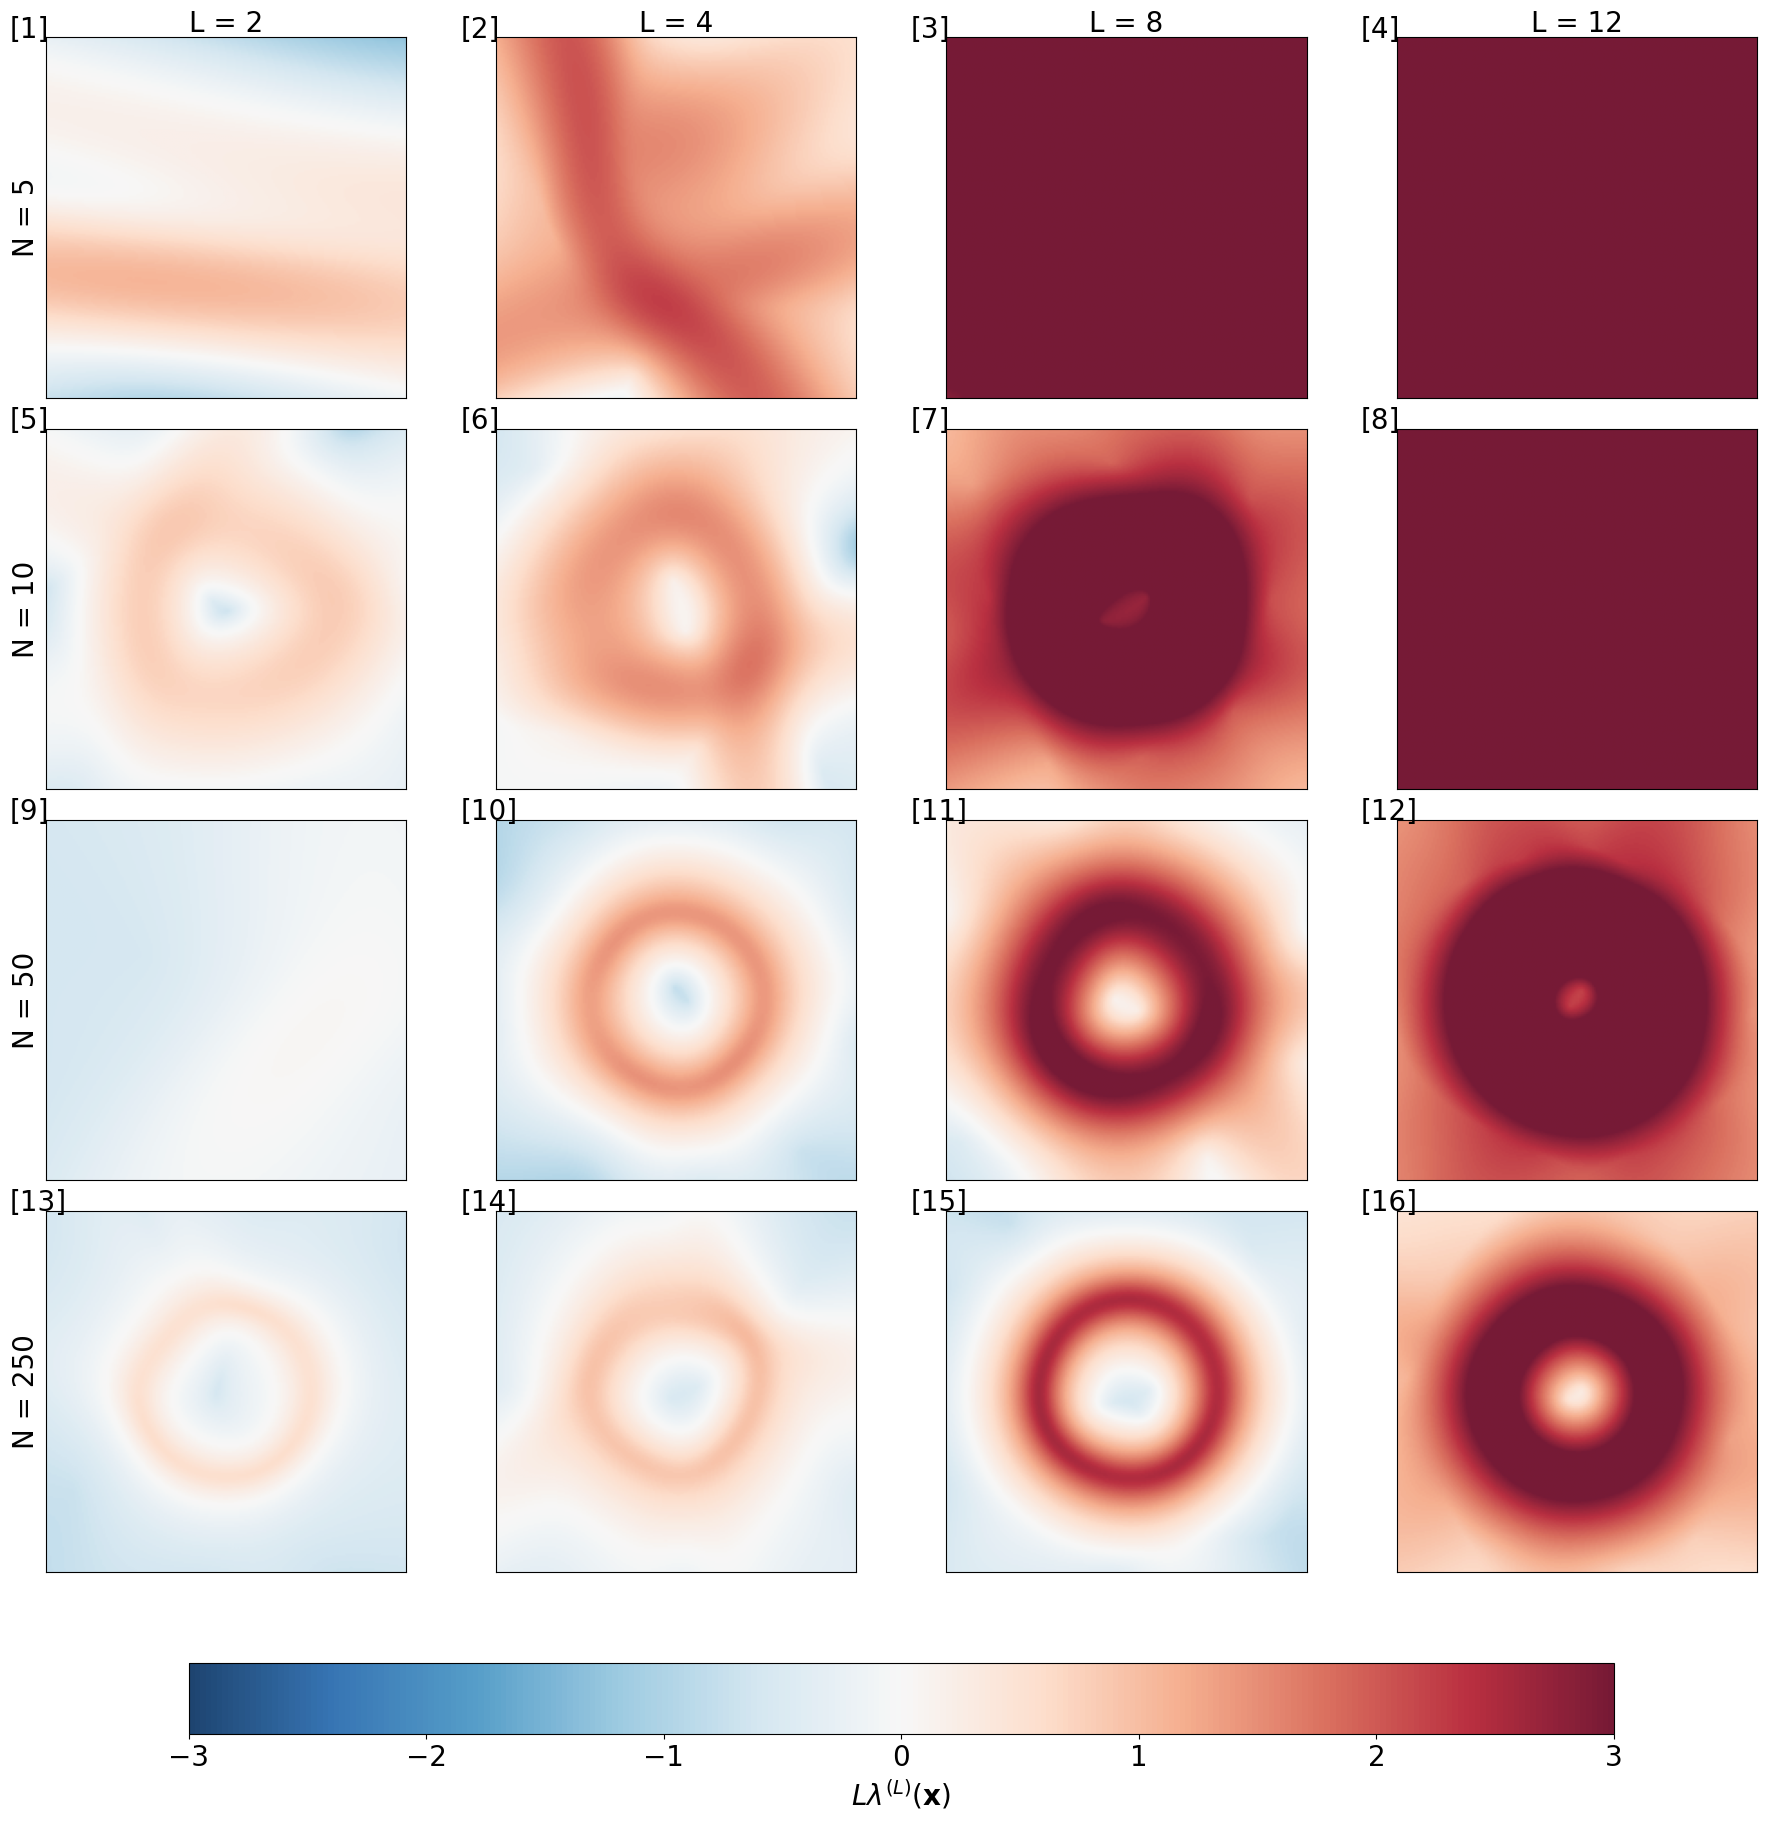

In [102]:

ell_list = [2, 4, 8, 12]
n_list = [5, 10, 50, 250]

fig = plt.figure(constrained_layout=True, figsize=(18,18), dpi=100)
axes = fig.subplots(4, 4)

# Iterate over each grid
for i, result in enumerate(networks_grid_tanh_ftle['circle'].values()):
    ax = axes[i%4, i//4]
    L = ell_list[i//4]
    lyapunov_exponents = L * result.reshape(nx, ny)
    
    # Plot the heatmap
    im = ax.imshow(lyapunov_exponents,
                   extent=[-1.5, 1.5, -1.5, 1.5],
                   origin='lower',
                   cmap='RdBu_r',
                   alpha=0.9,
                   norm=TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)) # vmin/vmax=-+4
    
    color_string = 'black' #'white' if (i%4 * 5 + i//4) + 1 in [2, 3, 4, 5, 10] else 'black'
    ax.text(-1.8, 1.5, f"[{(i%4 * 4 + i//4) + 1}]", color=color_string, fontsize=20)

    # Add vector field

    if not i % 4:
        ax.set_xlabel(f"L = {ell_list[i//4]}", fontsize=20)
        ax.xaxis.set_label_position('top') 
    if i in range(4):
        ax.set_ylabel(f"N = {n_list[i]}", fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

# Add a colorbar to the right of the figure
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='horizontal',
                    location='bottom',
                    shrink=0.8)
                    # fraction=0.08, pad=0.05)
cbar.set_label(r"$L\lambda^{(L)}(\mathbf{x})$",fontsize=20)
cbar.ax.tick_params(labelsize=20)
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.tick_top()
plt.show()